In [1]:
import pandas as pd
import numpy as np
from statsbombpy import sb
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('shots_data_refactored',index_col=0)

In [7]:
df.head()

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,counterpress,dribble_nutmeg,...,x,y,distance_from_goal,shot_angle,shot_type_Head,shot_type_Left Foot,shot_type_Other,shot_type_Right Foot,is_goal,baseline_xG
3817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,115.0,18.0,22.561028,4.638584,False,False,False,True,0,0.044775
3818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,112.0,54.0,16.124515,14.697319,False,False,False,True,0,0.111920
3819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,98.0,37.0,22.203603,20.252686,False,False,False,True,0,0.061170
3820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,119.0,36.0,4.123106,82.874984,True,False,False,False,0,0.304886
3821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,97.0,56.0,28.017851,13.456275,False,False,False,True,0,0.027050


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1706 entries, 3817 to 3641
Columns: 104 entries, 50_50 to baseline_xG
dtypes: bool(4), float64(67), int64(9), object(24)
memory usage: 1.3+ MB


In [9]:
df.columns.tolist()

['50_50',
 'bad_behaviour_card',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'block_offensive',
 'carry_end_location',
 'clearance_aerial_won',
 'counterpress',
 'dribble_nutmeg',
 'dribble_outcome',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_committed_penalty',
 'foul_committed_type',
 'foul_won_advantage',
 'foul_won_defensive',
 'foul_won_penalty',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_backheel',
 'pass_body_part',
 'pass_cross',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_length',
 'pass_outcome',
 'pass_recipient',
 'pass_recipient_id',
 'pass_shot_assist',
 'pass_switch',
 'pass_type',
 'perio

In [21]:
df['shot_freeze_frame'].iloc[1]
print(df['goalkeeper_position'].unique())

[nan]


In [11]:
# The Technical Logic: The "Triangle of Sight"
# To calculate this, we don't just count every player on the pitch. We define a geometric cone or triangle. The vertices are:
# The ball location (x, y).
# The left goalpost (120, 36).
# The right goalpost (120, 44).

# Any defender whose (x, y) coordinates fall inside that triangle is a "blocker."

In [34]:
def is_inside_shooting_triangle(px, py, ball_x, ball_y):
    area_of_sight = 0.5 * abs((ball_x*(36-44) + 120*(44-ball_y) + 120*(ball_y-36)))
    area_ball_player_right_post = 0.5 * abs((ball_x*(py-44) + px*(44-ball_y) + 120*(ball_y-py)))
    area_ball_player_left_post = 0.5 * abs((ball_x*(36-py) + px*(py-ball_y) + 120*(ball_y-36)))
    area_player_left_right_post = 0.5 * abs((px*(36-44) + 120*(44-py) + 120*(py-36)))
    
    # Check if the sum of the sub-triangles equals the main triangle
    if area_ball_player_left_post + area_ball_player_right_post + area_player_left_right_post < area_of_sight + 0.1:
        return True
    return False

def count_players_in_path(shot_event):
    freeze_frame = shot_event.get('shot_freeze_frame', [])
    
    if not isinstance(freeze_frame, list):
        return 0
    
    ball_x, ball_y = shot_event['location'][:2] 
    
    blockers = 0
    for player in freeze_frame:
        px, py = player['location'][:2]
        
        #Only count opponents (teammate == False)
        if player.get('teammate') == False:
            # only care about the players between the ball and the goal line
            if px > ball_x: 
                if is_inside_shooting_triangle(px, py, ball_x, ball_y):
                    blockers += 1
                    
    return blockers

df['blockers'] = df.apply(count_players_in_path, axis=1)

print(df[['distance_from_goal', 'shot_angle', 'blockers']].head(15))

      distance_from_goal  shot_angle  blockers
3817           22.561028    4.638584         0
3818           16.124515   14.697319         0
3819           22.203603   20.252686         0
3820            4.123106   82.874984         0
3821           28.017851   13.456275         0
3822           37.202150    9.950627         0
3823           19.924859   21.749535         0
3824           29.410882   14.780097         0
3825           22.847319   18.366982         0
3826           32.202484   11.514829         0
3827           25.942244   15.645481         0
3828           15.620499   22.833654         0
3829           12.000000   36.869898         0
3830           42.011903   10.874591         0
3831            8.544004   22.833654         0


In [35]:
df['blockers'].value_counts()

blockers
0    1706
Name: count, dtype: int64

In [36]:
import xgboost as xgb
from sklearn.metrics import log_loss , brier_score_loss

xgb_params = {
    'objective' : 'binary:logistic', # we want probabilites, not just 0s and 1s
    'eval_metric' : 'logloss', # evaluation metric
    'max_dept' : 4, # keep tress shallow prevents memorization
    'min_child_weight' : 20, # requires enough evidence (shots) in leaf to make a split
    'learning_rate' : 0.05,
    'subsample' : 0.8, # train each tree on 80% of data ( adds randomness/fights overfitting)
    'colsample_bytree' : 0.8 , # use 80% of features per tree
    'random_state' : 42
}


In [42]:
features = ['distance_from_goal','shot_angle','shot_type_Right Foot','shot_type_Head','shot_type_Left Foot','blockers']
X = df[features]
y = df['is_goal']

In [43]:
from sklearn.model_selection import train_test_split
X_train , X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

In [44]:
xgb_model = xgb.XGBClassifier(**xgb_params , n_estimators = 300)
print("Training the XGBoost xG model......")
xgb_model.fit(X_train,y_train)

Training the XGBoost xG model......


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [45]:
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

In [46]:
xgb_loss = log_loss(y_test , y_pred_proba_xgb)
xgb_brier = brier_score_loss(y_test,y_pred_proba_xgb)
print(f"XGBoost Log Loss : {xgb_loss}")
print(f"XGBoost Brier Score: {xgb_brier}")

XGBoost Log Loss : 0.27612402639252814
XGBoost Brier Score: 0.07619447261095047


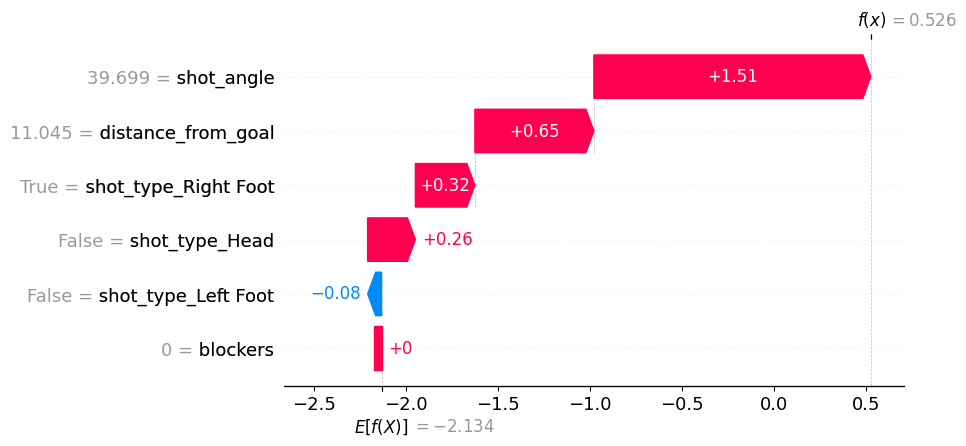

In [57]:
# Explaning feature importance
import shap
explainer = shap.TreeExplainer(xgb_model)
shot_to_explain = X_test.iloc[[1]]
shap_values = explainer(shot_to_explain)
shap.plots.waterfall(shap_values[0])

In [54]:
y_pred = xgb_model.predict(X_test)
print(y_pred)

[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [56]:
xgb_model.predict(X_test.iloc[[1]])

array([1])